# Method 4: Content + Public + Private = Hash

**Ainulindale Engine** — Tier udeo_crypto

Cody's equation, this session — exact vector algebra IF Hash is exposed (requires d). Not public-key-only. Some candidate collisions.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import importlib.util, math, cmath, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

def load_maths(tier):
    paths = {7: '../../modules/tier7_cosmos/maths.py',
             8: '../../modules/tier8_sedenion/maths.py',
             9: '../../modules/tier9_chem/maths.py',
             'udeo_crypto': '../../modules/udeo_crypto/UDEO_RSA_DEMO.py'}
    spec = importlib.util.spec_from_file_location(f't{tier}', paths[tier])
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m)
    return m

OMEGA_ZS = 0.5671432904097838
D_STAR   = 0.24600
GAP      = OMEGA_ZS - D_STAR * math.log(10)
R_H      = 1.0 / math.sqrt(2.0)
RIEMANN_ZEROS = [14.134725, 21.022040, 25.010858, 30.424876, 32.935062,
                 37.586178, 40.918719, 43.327073, 48.005151, 49.773832]
print("Ainulindale notebook ready.")


Ainulindale notebook ready.


In [2]:
m = load_maths('udeo_crypto')
result = m.method4_content_public_private_hash()
print("Claim:", result['claim'])
print("Confidence:", result['confidence'])


Claim: Method 4 (Content+Public+Private=Hash): does subtracting Hash recover d by search-matching against its embedding?
Confidence: CONJECTURE


## Engine Output

In [3]:
import pprint
pprint.pprint({k: v for k, v in result.items()
               if k not in ('claim', 'confidence', 'latex')}, width=100, depth=3)


{'chance_baseline': 50.0,
 'critical_caveat': 'This is NOT public-key-only key recovery. Hash = Content_s + Public_s + '
                    'Private_s requires d to compute in the first place — it is only usable by '
                    'someone who could already produce a value requiring the private key (e.g. a '
                    'one-time revealed signature-like artifact), not by an attacker holding only '
                    '(n, e). What this engine actually tests is narrower and still useful: IF such '
                    'a Hash value is ever exposed, does the vector algebra exactly and uniquely '
                    'identify d among a candidate pool, or does the lossy embedding '
                    "(map_int_to_hypercomplex) blur multiple candidates together? 'Exact and "
                    "unique' here would validate the embedding's injectivity, not a factoring or "
                    'key-recovery break.',
 'mean_percentile_rank': 0.0,
 'per_key': [{'control_mean_dist

## Mathematical Foundation

$$\text{LaTeX: }\quad C_s+Pu_s-H_s=-Pr_s$$

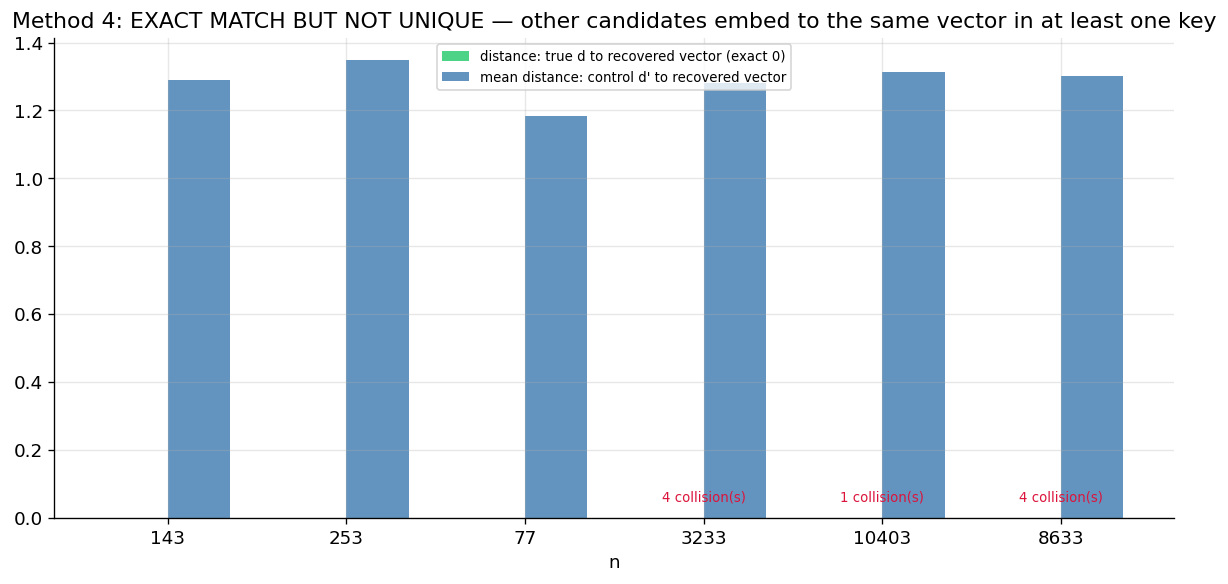

This is NOT public-key-only key recovery. Hash = Content_s + Public_s + Private_s requires d to compute in the first place — it is only usable by someone who could already produce a value requiring the private key (e.g. a one-time revealed signature-like artifact), not by an attacker holding only (n, e). What this engine actually tests is narrower and still useful: IF such a Hash value is ever exposed, does the vector algebra exactly and uniquely identify d among a candidate pool, or does the lossy embedding (map_int_to_hypercomplex) blur multiple candidates together? 'Exact and unique' here would validate the embedding's injectivity, not a factoring or key-recovery break.


In [4]:

fig, ax = plt.subplots(figsize=(10, 5))
rows = result['per_key']
ns = [str(row['n']) for row in rows]
true_dist = [row['true_d_distance_to_recovered_vector'] for row in rows]
ctrl_dist = [row['control_mean_distance'] for row in rows]
collisions = [row['exact_hash_collisions_with_true_d'] for row in rows]
x = np.arange(len(ns)); w = 0.35
ax.bar(x - w/2, true_dist, w, label='distance: true d to recovered vector (exact 0)', color='#2ECC71', alpha=0.85)
ax.bar(x + w/2, ctrl_dist, w, label='mean distance: control d\' to recovered vector', color='steelblue', alpha=0.85)
for xi, c in zip(x, collisions):
    if c > 0:
        ax.annotate(f'{c} collision(s)', (xi, 0.05), ha='center', fontsize=8, color='crimson')
ax.set_xticks(x); ax.set_xticklabels(ns); ax.set_xlabel('n')
ax.set_title(f"Method 4: {result['verdict']}")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(result['critical_caveat'])


## Ainulindale Reading

**Confidence:** `{}'.format(result.get('confidence',''))`

Run `result.keys()` to explore the full engine output.

In [5]:
print('Engine keys:', list(result.keys()))

Engine keys: ['claim', 'per_key', 'mean_percentile_rank', 'chance_baseline', 'verdict', 'confidence', 'critical_caveat']
